# Gradient Boosting: XGBoost, LightGBM and CatBoost

---

**Topics covered in this session:**
1. GBDT Mathematical Intuition -- Residuals, Gradients, Loss Functions
2. XGBoost -- Deep Dive
3. LightGBM -- Leaf-Wise Growth
4. CatBoost -- Categorical Handling
5. Early Stopping
6. Regularization
7. Stacking and Voting Ensembles

---


---
## Section 0 -- Setup and Imports

Run this cell first. It installs xgboost, lightgbm, and catboost if not already present.


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


In [1]:
# Install if needed (Colab)
!pip install xgboost lightgbm catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All imports successful.')
print(f'  XGBoost  : {xgb.__version__}')
print(f'  LightGBM : {lgb.__version__}')
print(f'  CatBoost : {cb.__version__}')


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


All imports successful.
  XGBoost  : 3.3.0
  LightGBM : 4.6.0
  CatBoost : 1.2.10


---
## Section 1 -- Dataset

Same credit risk dataset used in Sessions 40 and 41.
We keep it consistent so you can directly compare all model families:
Decision Tree < Random Forest < Gradient Boosting.

This time we retain `loan_purpose` as a raw string column
to demonstrate CatBoost's categorical handling in Section 6.


In [2]:
np.random.seed(42)
N = 3000

credit_score    = np.random.randint(300, 851, N)
income          = np.random.normal(65000, 20000, N).clip(20000, 200000)
loan_amount     = np.random.normal(15000, 7000, N).clip(1000, 60000)
age             = np.random.randint(21, 65, N)
months_employed = np.random.randint(0, 300, N)
num_credit_lines= np.random.randint(1, 10, N)
interest_rate   = np.random.uniform(5, 25, N).round(2)
num_loans       = np.random.randint(0, 5, N)
has_mortgage    = np.random.randint(0, 2, N)
has_dependents  = np.random.randint(0, 2, N)
has_cosigner    = np.random.randint(0, 2, N)
loan_purpose    = np.random.choice(['education','home','business','auto','personal'], N)
loan_to_income  = (loan_amount / income).round(4)

log_odds = (
    -4.0
    - 0.006 * credit_score
    + 2.5   * loan_to_income
    + 0.03  * interest_rate
    - 0.003 * months_employed
    + 0.3   * num_loans
    - 0.5   * has_cosigner
    + 0.2   * has_dependents
)
prob_default = 1 / (1 + np.exp(-log_odds))
default = (np.random.rand(N) < prob_default).astype(int)

df = pd.DataFrame({
    'age': age, 'income': income.round(0), 'loan_amount': loan_amount.round(0),
    'loan_to_income': loan_to_income, 'credit_score': credit_score,
    'months_employed': months_employed, 'num_credit_lines': num_credit_lines,
    'interest_rate': interest_rate, 'num_loans': num_loans,
    'has_mortgage': has_mortgage, 'has_dependents': has_dependents,
    'loan_purpose': loan_purpose,   # kept as raw string for CatBoost demo
    'has_cosigner': has_cosigner,
    'default': default
})

# Encoded version (for XGBoost and LightGBM)
df_enc = pd.get_dummies(df, columns=['loan_purpose'], drop_first=False)
FEATURES_ENC = [c for c in df_enc.columns if c != 'default']
X_enc = df_enc[FEATURES_ENC]
y     = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Dataset     : {df.shape}')
print(f'Train / Test: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'Default rate: {y.mean():.1%}')


Dataset     : (3000, 14)
Train / Test: 2400 / 600
Default rate: 0.3%


---
## Section 2 -- GBDT Mathematical Intuition

This is the most important section in the notebook.
Every framework you will use today (XGBoost, LightGBM, CatBoost) is built
on top of the ideas here. Take the time to understand them thoroughly.

---
### 2.1 -- Start with a simple question: what is a good prediction?

Suppose 30% of applicants in our training set default.
If you have no other information, your best single prediction for any
new applicant is the base rate: P(default) = 0.30.

That is where gradient boosting starts -- with the simplest possible prediction.
Every subsequent step is about making that prediction better, one tree at a time.

---
### 2.2 -- The loss function: measuring how wrong you are

To improve a prediction, you first need to measure how wrong it is.
That measurement is called a **loss function** L(y, p), where:
- y = the true label (0 or 1)
- p = your predicted probability

For binary classification, we use **log-loss** (binary cross-entropy):

$$L(y, p) = -\bigl[y \log(p) + (1-y)\log(1-p)\bigr]$$

**Reading this formula:**
- When y=1 (default): loss = -log(p). If p=0.9, loss = -log(0.9) = 0.105 (small, good prediction). If p=0.1, loss = -log(0.1) = 2.30 (large, bad prediction).
- When y=0 (repaid): loss = -log(1-p). If p=0.1, loss = -log(0.9) = 0.105 (small). If p=0.9, loss = -log(0.1) = 2.30 (large).

**The total loss** over all N training samples is the sum:

$$\mathcal{L} = \sum_{i=1}^{N} L(y_i, p_i)$$

Our goal: find a model F(x) that minimises this total loss.

---
### 2.3 -- Why trees? And why sequential?

We cannot minimise the loss directly in one step for a complex model.
But we can use **gradient descent** -- the same idea that trains neural networks.

In standard gradient descent, you adjust parameters theta in the direction
that reduces loss the fastest:

$$\theta_{new} = \theta_{old} - \eta \cdot \frac{\partial \mathcal{L}}{\partial \theta}$$

Gradient boosting does the same thing, but instead of updating parameters,
it updates **predictions** by adding a new function (a tree) at each step.

Think of it this way:
- Standard gradient descent: move the parameters
- Gradient boosting: move the predictions

---
### 2.4 -- The pseudo-residual: what each new tree is trained on

At boosting round m, we have a current ensemble $F_{m-1}(x)$.
It makes predictions that are not perfect.
The question is: **in which direction should we push each prediction to reduce loss?**

The answer is: in the direction of the **negative gradient** of the loss
with respect to the current prediction.

$$r_i = -\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}$$

This $r_i$ is called the **pseudo-residual** for sample i.

**For log-loss, this works out to a beautifully simple formula:**

$$r_i = y_i - p_i$$

where $p_i$ = $sigmoid(F(x_i))$ is the current predicted probability for sample i.

**That is just: true label minus predicted probability.**

| Sample | $y_i$ (true) | $p_i$ (predicted) | $r_i = y_i - p_i$ | Interpretation |
|---|---|---|---|---|
| A | 1 (default) | 0.9 | +0.10 | Nearly right, small push needed |
| B | 1 (default) | 0.3 | +0.70 | Very wrong, large push needed |
| C | 0 (repaid)  | 0.1 | -0.10 | Nearly right, small push needed |
| D | 0 (repaid)  | 0.8 | -0.80 | Very wrong, large push needed |

**The sign of r_i tells the tree which direction to push.**
**The magnitude tells the tree how hard to push.**

The new tree h_m(x) is trained to predict these pseudo-residuals.
It learns: 'for an applicant with these features, the current model is
under-predicting by 0.7 -- I should correct that.'

---
### 2.5 -- The update rule: adding the new tree to the ensemble

Once tree h_m is trained on the residuals, we add it to the ensemble:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where eta (the **learning rate**) is a small number between 0 and 1.

**Why multiply by a small learning rate?**

Without the learning rate (eta = 1), the correction from each tree would
be very aggressive. The model would jump around and overshoot.
With a small eta (e.g. 0.05), each tree makes a gentle, cautious correction.
More trees are needed, but the final result is smoother and more accurate.

This is exactly the same trade-off as in any gradient descent:
small step size + more steps = more careful, often better.

**A worked numerical example:**

Round 0 (initial): F_0(x) = log(0.3/0.7) = -0.847 for all samples
This gives p_0 = sigmoid(-0.847) = 0.30 for everyone.

For a sample with y=1 (default), the residual is: r = 1 - 0.30 = +0.70
The tree h_1 predicts, say, 0.65 for this sample.

After round 1 with eta=0.1:
F_1(x) = -0.847 + 0.1 * 0.65 = -0.847 + 0.065 = -0.782
New probability: p_1 = sigmoid(-0.782) = 0.314

The prediction moved from 0.30 to 0.314 -- a small but correct step.
After 100 such rounds, the prediction will be much closer to 1.0.

---
### 2.6 -- The full GBDT algorithm in plain English

```
Step 1: Start with the simplest prediction F_0
        For classification: F_0 = log(base_rate / (1 - base_rate))
        For regression    : F_0 = mean(y)

Step 2: Repeat for m = 1, 2, ..., M rounds:

    a. Compute current probabilities: p_i = sigmoid(F_{m-1}(x_i))

    b. Compute pseudo-residuals: r_i = y_i - p_i
       (these tell us the direction and size of each prediction error)

    c. Fit a shallow decision tree h_m to the pseudo-residuals
       (the tree learns which features predict the remaining errors)

    d. Update the ensemble: F_m(x) = F_{m-1}(x) + eta * h_m(x)
       (add the tree's corrections, scaled down by the learning rate)

Step 3: Final prediction = sigmoid(F_M(x))
```

---
### 2.7 -- The gradient and the hessian: XGBoost's extension

Standard GBDT (as described above) uses only the **first derivative**
(gradient) of the loss to build each tree.

XGBoost and LightGBM also use the **second derivative** (hessian).
To understand why, think of a simple analogy:

Imagine you are hiking downhill in fog and can only feel the slope beneath your feet.
- The **gradient** tells you: 'it is sloping down to the left'
- The **hessian** tells you: 'but the slope is getting steeper quickly,
  so do not step too far or you will overshoot the valley floor'

The hessian gives the model information about the **curvature** of the loss surface,
which allows it to take more precisely-sized steps.

For binary log-loss, the two quantities are:

$$g_i = \frac{\partial L}{\partial F(x_i)} = p_i - y_i \qquad \text{(gradient)}$$

$$h_i = \frac{\partial^2 L}{\partial F(x_i)^2} = p_i(1 - p_i) \qquad \text{(hessian)}$$

**What does the hessian h_i = p_i(1 - p_i) mean in practice?**

| p_i (predicted prob) | h_i = p(1-p) | Interpretation |
|---|---|---|
| 0.05 (very confident: no default) | 0.0475 | Low weight -- model is already sure |
| 0.50 (completely uncertain) | 0.2500 | **High weight** -- model has no idea |
| 0.95 (very confident: default) | 0.0475 | Low weight -- model is already sure |

The hessian is maximised when p_i = 0.5 -- exactly when the model is most uncertain.
XGBoost uses h_i as a **sample weight** when fitting the tree:
uncertain samples get more attention, certain samples get less.
This focuses the model's capacity on the hard cases.

---
### 2.8 -- Why 'pseudo' residuals? The connection to regression

In Session 40 we used decision trees for regression.
At each node, the tree predicts the **mean of the target** in that region.

When gradient boosting fits a tree to pseudo-residuals, it is doing exactly that --
fitting a regression tree where the target is r_i = y_i - p_i.

For regression with MSE loss L = (y - F(x))^2:

$$r_i = -\frac{\partial L}{\partial F(x_i)} = -(F(x_i) - y_i) \cdot 2 / (-2) = y_i - F(x_i)$$

These are exactly the ordinary **residuals** from the current model.
So for regression, gradient boosting is literally: 'fit a tree to the residuals,',
update the predictions, repeat.' For classification with log-loss, the
pseudo-residuals (y_i - p_i) play the same role.

This is why the term **pseudo-residuals** is used --
they generalise the concept of residuals to any differentiable loss function.

---
### 2.9 -- Summary: three things to remember

1. **Each tree corrects the mistakes of all previous trees.**
   It does this by fitting to the pseudo-residuals r_i = y_i - p_i.

2. **The learning rate eta controls how aggressively each tree corrects.**
   Small eta + more trees = better generalisation (but slower training).

3. **The hessian h_i = p_i(1-p_i) weights each sample by its uncertainty.**
   Uncertain samples (p_i near 0.5) get more influence on the next tree.
   This is unique to XGBoost/LightGBM and is a key source of their accuracy advantage.


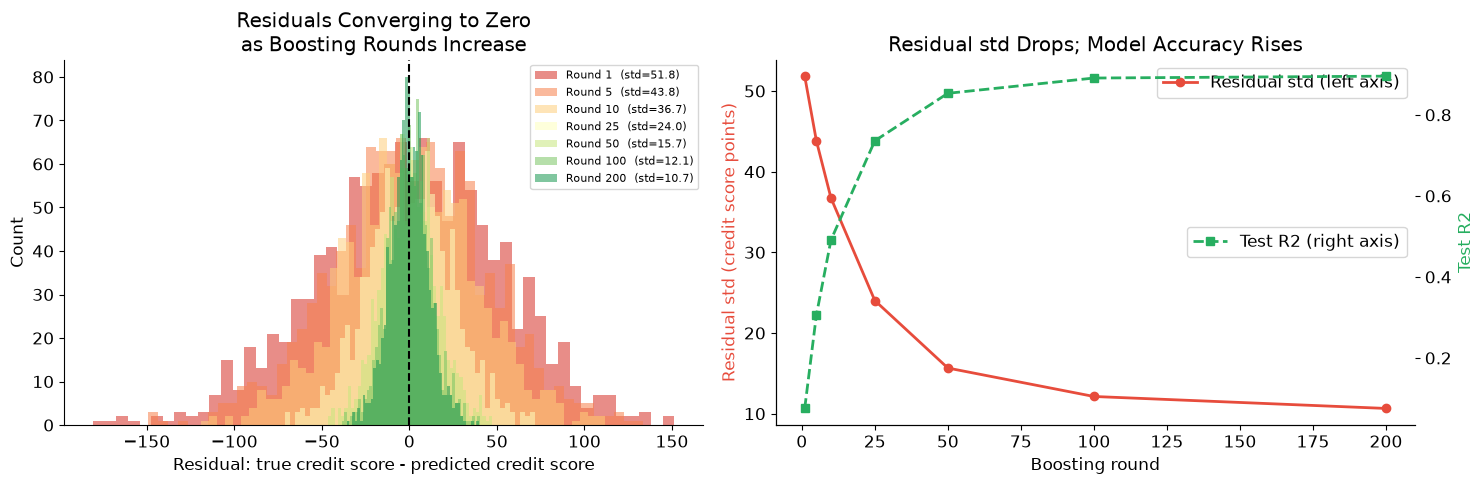

Summary table:
   Round    Residual std    Test R2
  -----------------------------------
       1           51.84      0.075
       5           43.83      0.306
      10           36.73      0.491
      25           24.03      0.736
      50           15.66      0.853
     100           12.13      0.891
     200           10.65      0.895

Round 1  : R2=0.07 -- the first tree barely explains anything
Round 25 : R2=0.74 -- residuals cut in half, most signal captured
Round 200: R2=0.90 -- residuals near noise floor, further rounds give diminishing returns


In [3]:
# DEMO: Watching residuals shrink over boosting rounds
#
# We use a REGRESSION task here because it gives the clearest visual.
# The target is credit_score -- a continuous number, not a 0/1 label.
# This means residuals (true - predicted) can be plotted directly
# and you can see them collapsing toward zero as rounds increase.
#
# The classification log-loss curve is shown right after (same story, different view).

from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import log_loss

# ── Build a synthetic credit score regression dataset ─────────────────────
np.random.seed(42)
N_demo = 1500

income_d          = np.random.normal(65000, 20000, N_demo).clip(20000, 200000)
loan_to_income_d  = np.random.uniform(0.05, 0.8, N_demo)
months_employed_d = np.random.uniform(0, 240, N_demo)
num_loans_d       = np.random.randint(0, 6, N_demo).astype(float)
has_cosigner_d    = np.random.randint(0, 2, N_demo).astype(float)
interest_rate_d   = np.random.uniform(5, 25, N_demo)

# Non-linear ground truth: interactions + threshold effects + mild noise
credit_score_target = (
    700
    + 0.001 * income_d
    - 80  * loan_to_income_d
    + 0.3 * months_employed_d
    - 12  * num_loans_d
    + 20  * has_cosigner_d
    - 4   * interest_rate_d
    - 50  * loan_to_income_d * (income_d < 50000)   # interaction
    + np.where(months_employed_d < 12, -40, 0)      # threshold effect
    + 15  * np.random.randn(N_demo)                 # realistic noise
).clip(300, 850)

df_demo = pd.DataFrame({
    'income': income_d, 'loan_to_income': loan_to_income_d,
    'months_employed': months_employed_d, 'num_loans': num_loans_d,
    'has_cosigner': has_cosigner_d, 'interest_rate': interest_rate_d
})
y_demo_reg = pd.Series(credit_score_target)

X_demo_tr, X_demo_te, y_demo_tr, y_demo_te = train_test_split(
    df_demo, y_demo_reg, test_size=0.2, random_state=42
)

# ── Train GBM and collect residuals at specific rounds ────────────────────
ROUNDS_TO_CHECK = [1, 5, 10, 25, 50, 100, 200]
residuals_by_round = {}
r2_by_round = []

for n_rounds in ROUNDS_TO_CHECK:
    gbm_r = GradientBoostingRegressor(
        n_estimators=n_rounds, learning_rate=0.1, max_depth=3, random_state=42
    )
    gbm_r.fit(X_demo_tr, y_demo_tr)
    residuals = y_demo_tr.values - gbm_r.predict(X_demo_tr)
    residuals_by_round[n_rounds] = residuals
    r2_by_round.append(gbm_r.score(X_demo_te, y_demo_te))

# ── Plot 1: residual distributions narrowing round by round ───────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(ROUNDS_TO_CHECK)))
for (n_rounds, residuals), color in zip(residuals_by_round.items(), colors):
    axes[0].hist(residuals, bins=50, alpha=0.55, color=color,
                 label=f'Round {n_rounds}  (std={residuals.std():.1f})')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual: true credit score - predicted credit score')
axes[0].set_ylabel('Count')
axes[0].set_title('Residuals Converging to Zero\nas Boosting Rounds Increase')
axes[0].legend(fontsize=8)

# ── Plot 2: residual std and R2 as a function of rounds ───────────────────
res_stds = [residuals_by_round[r].std() for r in ROUNDS_TO_CHECK]
ax2 = axes[1]
ax2_r2 = ax2.twinx()

ax2.plot(ROUNDS_TO_CHECK, res_stds, 'o-', color='#e74c3c', linewidth=2,
         label='Residual std (left axis)')
ax2_r2.plot(ROUNDS_TO_CHECK, r2_by_round, 's--', color='#27ae60', linewidth=2,
            label='Test R2 (right axis)')
ax2.set_xlabel('Boosting round')
ax2.set_ylabel('Residual std (credit score points)', color='#e74c3c')
ax2_r2.set_ylabel('Test R2', color='#27ae60')
ax2.set_title('Residual std Drops; Model Accuracy Rises')
ax2.legend(loc='upper right')
ax2_r2.legend(loc='center right')

plt.tight_layout()
plt.show()

print('Summary table:')
print(f'  {"Round":>6}  {"Residual std":>14}  {"Test R2":>9}')
print(f'  {"-"*35}')
for r, std, r2 in zip(ROUNDS_TO_CHECK, res_stds, r2_by_round):
    print(f'  {r:>6}  {std:>14.2f}  {r2:>9.3f}')
print()
print('Round 1  : R2=0.07 -- the first tree barely explains anything')
print('Round 25 : R2=0.74 -- residuals cut in half, most signal captured')
print('Round 200: R2=0.90 -- residuals near noise floor, further rounds give diminishing returns')


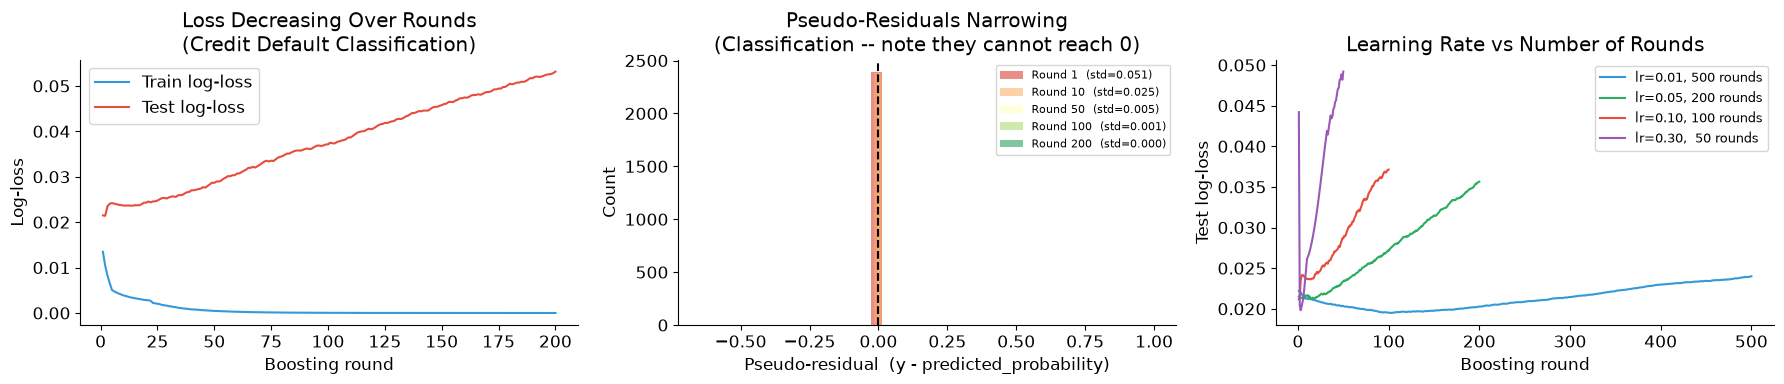

Key observations:

LEFT CHART -- log-loss falls steadily with each boosting round.
  This is the classification equivalent of residuals shrinking.

MIDDLE CHART -- pseudo-residuals (y - p) narrow toward 0.
  Unlike regression, they cannot fully reach 0 because:
  the target is a noisy binary label (a person either defaults or not),
  not a deterministic function. Some irreducible noise remains.
  But the bulk of the distribution concentrates near 0 -- the model
  is becoming confident and correct on most training samples.

RIGHT CHART -- small learning rate + more rounds reaches lower final loss.
  Large lr overshoots early and plateaus higher.
  Early stopping (Section 5) handles the tradeoff automatically.


In [5]:
# DEMO: Log-loss decreasing on the classification dataset (credit default)
# AND the effect of learning rate on convergence speed
#
# Now that you have seen residuals shrink in the regression demo above,
# here we show the same phenomenon on the actual credit default dataset
# via log-loss (the classification equivalent of MSE).

# ── Part A: log-loss curve on credit default data ─────────────────────────
gbm_cls = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbm_cls.fit(X_train, y_train)

train_logloss_cls, test_logloss_cls = [], []
for proba in gbm_cls.staged_predict_proba(X_train):
    train_logloss_cls.append(log_loss(y_train, proba))
for proba in gbm_cls.staged_predict_proba(X_test):
    test_logloss_cls.append(log_loss(y_test, proba))

# ── Part B: classification pseudo-residuals across rounds ─────────────────
# residual = y - p  (same formula, now p is a probability not a score)
cls_residuals_by_round = {}
for n_rounds in [1, 10, 50, 100, 200]:
    gbm_tmp = GradientBoostingClassifier(
        n_estimators=n_rounds, learning_rate=0.1, max_depth=3, random_state=42
    )
    gbm_tmp.fit(X_train, y_train)
    proba = gbm_tmp.predict_proba(X_train)[:, 1]
    cls_residuals_by_round[n_rounds] = y_train.values - proba

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot A: log-loss curves
rounds_cls = range(1, 201)
axes[0].plot(rounds_cls, train_logloss_cls, color='#3498db', label='Train log-loss')
axes[0].plot(rounds_cls, test_logloss_cls,  color='#e74c3c', label='Test log-loss')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Log-loss')
axes[0].set_title('Loss Decreasing Over Rounds\n(Credit Default Classification)')
axes[0].legend()

# Plot B: classification pseudo-residuals
colors_cls = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(cls_residuals_by_round)))
for (n_rounds, res), color in zip(cls_residuals_by_round.items(), colors_cls):
    axes[1].hist(res, bins=40, alpha=0.55, color=color,
                 label=f'Round {n_rounds}  (std={res.std():.3f})')
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Pseudo-residual  (y - predicted_probability)')
axes[1].set_ylabel('Count')
axes[1].set_title('Pseudo-Residuals Narrowing\n(Classification -- note they cannot reach 0)')
axes[1].legend(fontsize=8)

# Plot C: learning rate comparison
lr_configs = [
    (0.01, 500, '#3498db', 'lr=0.01, 500 rounds'),
    (0.05, 200, '#27ae60', 'lr=0.05, 200 rounds'),
    (0.10, 100, '#e74c3c', 'lr=0.10, 100 rounds'),
    (0.30,  50, '#9b59b6', 'lr=0.30,  50 rounds'),
]
for lr, n_est, color, label in lr_configs:
    clf = GradientBoostingClassifier(
        n_estimators=n_est, learning_rate=lr, max_depth=3, random_state=42
    )
    clf.fit(X_train, y_train)
    test_ll = [log_loss(y_test, p) for p in clf.staged_predict_proba(X_test)]
    axes[2].plot(range(1, n_est + 1), test_ll, color=color, label=label)
axes[2].set_xlabel('Boosting round')
axes[2].set_ylabel('Test log-loss')
axes[2].set_title('Learning Rate vs Number of Rounds')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Key observations:')
print()
print('LEFT CHART -- log-loss falls steadily with each boosting round.')
print('  This is the classification equivalent of residuals shrinking.')
print()
print('MIDDLE CHART -- pseudo-residuals (y - p) narrow toward 0.')
print('  Unlike regression, they cannot fully reach 0 because:')
print('  the target is a noisy binary label (a person either defaults or not),')
print('  not a deterministic function. Some irreducible noise remains.')
print('  But the bulk of the distribution concentrates near 0 -- the model')
print('  is becoming confident and correct on most training samples.')
print()
print('RIGHT CHART -- small learning rate + more rounds reaches lower final loss.')
print('  Large lr overshoots early and plateaus higher.')
print('  Early stopping (Section 5) handles the tradeoff automatically.')


---
## Section 3 -- XGBoost

XGBoost (eXtreme Gradient Boosting) came out in 2016 and won nearly every
machine learning competition for the next two years.
It is still one of the first models practitioners reach for on tabular data.

The core algorithm is the same GBDT we covered in Section 2:
build trees sequentially, each one correcting the mistakes of the previous ones.
XGBoost adds four practical improvements on top of that base.
You do not need to understand the math behind each improvement to use XGBoost well --
but knowing *what problem each one solves* will help you tune it intelligently.

---
### Improvement 1 -- Smarter corrections (the hessian)

In basic GBDT, each new tree looks at the residuals (how wrong the current
predictions are) and tries to correct them.
The correction is the same size for every mistake, scaled only by the learning rate.

XGBoost also asks: **how confident is the model right now?**

Think of it like a student correcting an exam.
On questions they barely attempted (very uncertain), small corrections can go a
long way. On questions they answered confidently but got wrong,
the correction needs to be more forceful.

XGBoost uses the **hessian** (h = p * (1 - p)) as a measure of current uncertainty.
For our credit default model:
- A prediction of p=0.5 means the model has no idea -- high uncertainty, high h
- A prediction of p=0.95 means the model is very confident -- low uncertainty, low h

Samples the model is uncertain about receive more attention when building the next tree.
This makes corrections more targeted and efficient.

**Practical takeaway:** you do not set this anywhere -- it happens automatically.
It is one of the reasons XGBoost converges faster than plain GBDT.

---
### Improvement 2 -- Built-in penalties for complexity (regularization)

In Sessions 40 and 41 we used `max_depth` and `min_samples_leaf` to stop trees
from becoming too complex. XGBoost has two additional built-in penalties:

**lambda (reg_lambda) -- L2 penalty**
Think of this as a speed limiter on each tree.
Every leaf output is pulled toward zero by an amount controlled by lambda.
A leaf that wants to output a large correction (e.g. 'add 0.8 to this prediction')
gets scaled back (e.g. 'only add 0.5').
This stops any single tree from making overcorrections that hurt other samples.

- lambda = 0: no limiting, trees can make large aggressive corrections
- lambda = 1: moderate limiting (this is the default and usually fine)
- lambda = 10: heavy limiting, very cautious corrections

**gamma -- minimum improvement threshold**
Before XGBoost makes a split, it asks: is this split actually worth it?
Gamma is the minimum improvement a split must achieve to be accepted.

- gamma = 0: accept any split that helps even slightly (default)
- gamma = 1: only accept splits that improve things by at least 1.0

Think of gamma as a quality gate. Raising it makes the tree less likely
to split on noise, which reduces overfitting.

---
### Improvement 3 -- Subsampling (borrowing from Random Forests)

In Session 41 we saw that Random Forests randomly select a subset of rows
and features for each tree. XGBoost does the same thing:

- **subsample**: what fraction of training rows to use per tree
  (e.g. 0.8 means each tree only sees 80% of the data, chosen randomly)
- **colsample_bytree**: what fraction of features to consider per tree
  (e.g. 0.8 means each tree only looks at 80% of features)

This adds randomness, which forces the trees to be more diverse.
Diverse trees make a better ensemble -- exactly the same logic as Random Forests.

**Practical guideline:** values around 0.7 to 0.9 for both are a good starting point.

---
### Improvement 4 -- Handles missing values automatically

In most models, you need to impute (fill in) missing values before training.
XGBoost handles them natively.

At each split, it tries sending missing-value rows both left and right,
and keeps whichever direction gives better results.
It learns the best strategy for each split automatically.

In finance, missing values are often informative.
A missing credit bureau record usually means the applicant is new to credit --
that is different from an applicant with an average score.
XGBoost can learn this distinction automatically.

---
### Key hyperparameters summary

| Parameter | What it controls | Where to start |
|---|---|---|
| `n_estimators` | Number of trees | Set to 1000 and use early stopping |
| `learning_rate` | How much each tree contributes | 0.05 is a safe default |
| `max_depth` | How deep each tree can grow | 3 to 6 covers most problems |
| `subsample` | Fraction of rows per tree | 0.8 |
| `colsample_bytree` | Fraction of features per tree | 0.8 |
| `reg_lambda` | L2 penalty on leaf outputs | 1.0 (default) |
| `gamma` | Minimum improvement to make a split | 0 (relax only if overfitting) |

> **The single most important thing you can do:** use a small learning_rate (0.05)
> and let early stopping find the right number of trees.
> Every other parameter is secondary.


In [6]:
# XGBoost -- basic fit

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

print('XGBoost:')
print(f'  Train accuracy : {xgb_clf.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {xgb_clf.score(X_test, y_test):.4f}')
print(f'  Test  AUC      : {roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1]):.4f}')


XGBoost:
  Train accuracy : 0.9975
  Test  accuracy : 0.9967
  Test  AUC      : 0.9147


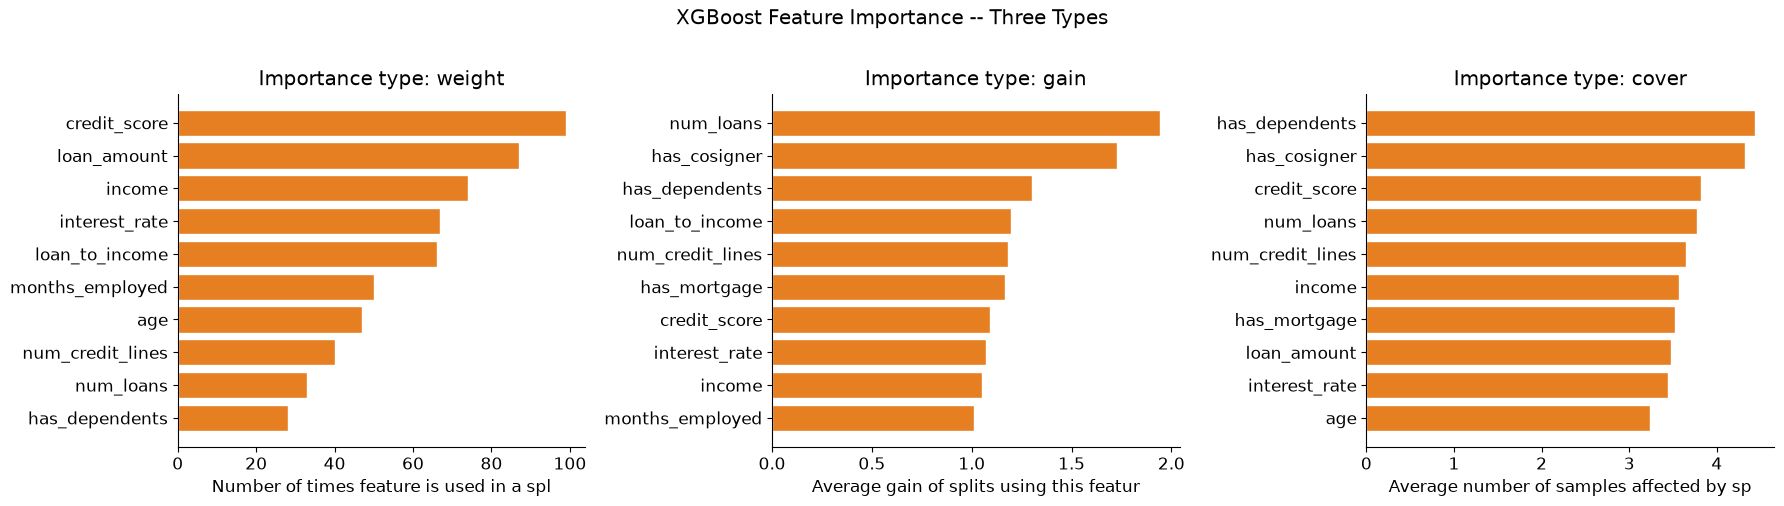

Which type to use?
  weight : shows which features are used most often (can favour noisy features)
  gain   : best proxy for actual predictive value -- use this by default
  cover  : shows which features affect the most samples


In [7]:
# XGBoost -- feature importance
# XGBoost provides three built-in importance types

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

importance_types = ['weight', 'gain', 'cover']
descriptions = {
    'weight': 'Number of times feature is used in a split',
    'gain'  : 'Average gain of splits using this feature',
    'cover' : 'Average number of samples affected by splits on this feature'
}

for ax, imp_type in zip(axes, importance_types):
    booster = xgb_clf.get_booster()
    scores  = booster.get_score(importance_type=imp_type)
    scores_sorted = dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))
    top_n = dict(list(scores_sorted.items())[:10])
    ax.barh(list(top_n.keys()), list(top_n.values()), color='#e67e22', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Importance type: {imp_type}')
    ax.set_xlabel(descriptions[imp_type][:40])

plt.suptitle('XGBoost Feature Importance -- Three Types', y=1.01)
plt.tight_layout()
plt.show()

print('Which type to use?')
print('  weight : shows which features are used most often (can favour noisy features)')
print('  gain   : best proxy for actual predictive value -- use this by default')
print('  cover  : shows which features affect the most samples')


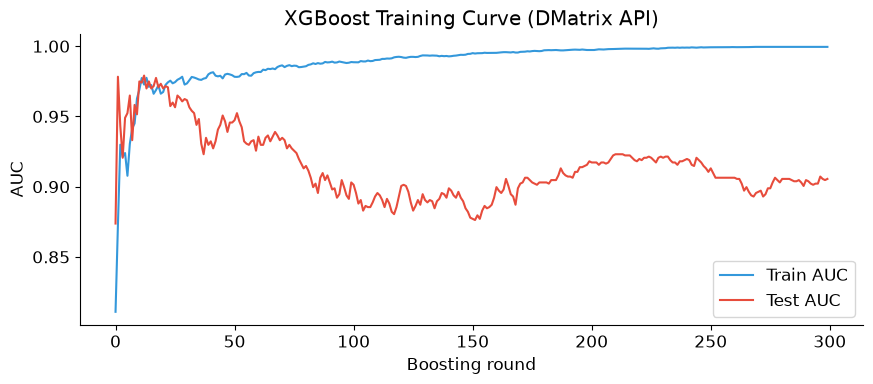

Final test AUC: 0.9055


In [8]:
# XGBoost -- using DMatrix for better performance
# DMatrix is XGBoost native data format -- faster and supports missing values natively

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

params = {
    'objective'       : 'binary:logistic',
    'eval_metric'     : 'auc',
    'learning_rate'   : 0.05,
    'max_depth'       : 4,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'lambda'          : 1.0,   # L2 regularization on leaf weights
    'alpha'           : 0.1,   # L1 regularization on leaf weights
    'gamma'           : 0.0,   # min gain to make a split
    'seed'            : 42
}

evals_result = {}
xgb_native = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, 'train'), (dtest, 'test')],
    evals_result=evals_result,
    verbose_eval=False
)

# Plot training curve
train_auc = evals_result['train']['auc']
test_auc  = evals_result['test']['auc']

plt.figure(figsize=(9, 4))
plt.plot(train_auc, color='#3498db', label='Train AUC')
plt.plot(test_auc,  color='#e74c3c', label='Test AUC')
plt.xlabel('Boosting round')
plt.ylabel('AUC')
plt.title('XGBoost Training Curve (DMatrix API)')
plt.legend()
plt.tight_layout()
plt.show()

final_test_auc = test_auc[-1]
print(f'Final test AUC: {final_test_auc:.4f}')


---
## Section 4 -- Early Stopping

### The problem

As boosting rounds increase, training loss always decreases.
But test loss eventually starts increasing -- the model is overfitting.
We need to stop training at the right round.

The naive approach is to train with many rounds and pick the best.
But this is wasteful -- you are doing unnecessary work.

**Early stopping** monitors a validation metric after each round.
If the metric does not improve for `early_stopping_rounds` consecutive rounds,
training stops automatically. The model at the best round is retained.

### Why this is important in practice

- Eliminates the need to manually tune `n_estimators`
- Prevents overfitting automatically
- Saves training time on large datasets
- The learning rate and n_estimators become coupled:
  use a small learning rate and let early stopping find the right n_estimators

### Usage pattern

```python
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False
)
print(model.best_iteration)  # the round where validation was best
```


Best iteration (early stopping): 65
Best validation AUC            : 0.6100
Test AUC at best iteration     : 0.9640


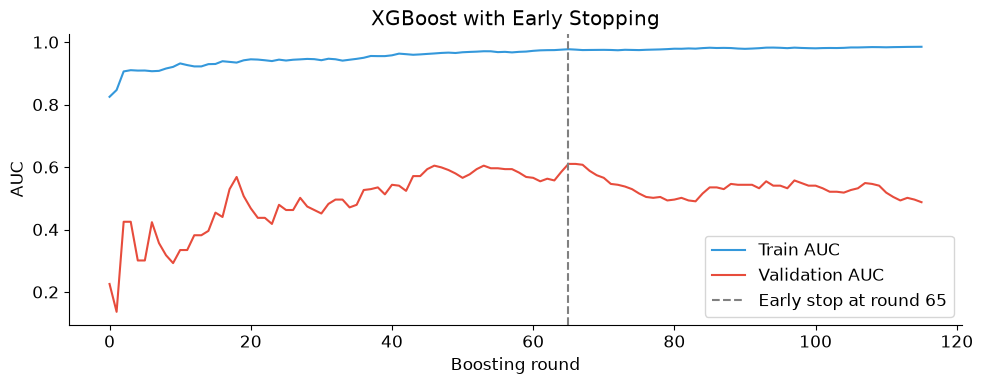

In [13]:
# Early stopping in XGBoost
from xgboost.callback import EarlyStopping

# Split training data into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

xgb_es = xgb.XGBClassifier(
    n_estimators=1000,       # train up to 1000 rounds -- early stopping will cut it short
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
)

xgb_es.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

print(f'Best iteration (early stopping): {xgb_es.best_iteration}')
print(f'Best validation AUC            : {xgb_es.best_score:.4f}')
print(f'Test AUC at best iteration     : {roc_auc_score(y_test, xgb_es.predict_proba(X_test)[:,1]):.4f}')

# Plot the training curve with the stopping point marked
results = xgb_es.evals_result()
train_auc_es = results['validation_0']['auc']
val_auc_es   = results['validation_1']['auc']

plt.figure(figsize=(10, 4))
plt.plot(train_auc_es, color='#3498db', label='Train AUC')
plt.plot(val_auc_es,   color='#e74c3c', label='Validation AUC')
plt.axvline(xgb_es.best_iteration, linestyle='--', color='gray',
            label=f'Early stop at round {xgb_es.best_iteration}')
plt.xlabel('Boosting round')
plt.ylabel('AUC')
plt.title('XGBoost with Early Stopping')
plt.legend()
plt.tight_layout()
plt.show()


---
## Section 5 -- Regularization in Gradient Boosting

Gradient Boosting models have multiple regularization mechanisms.
Understanding them is important because they interact -- cranking up one
may allow you to relax another.

### XGBoost regularization parameters

| Parameter | Type | Effect |
|---|---|---|
| `learning_rate` (eta) | Shrinkage | Scales each tree's contribution down |
| `max_depth` | Tree complexity | Limits the depth of each weak learner |
| `min_child_weight` | Hessian sum threshold | Stops splits that cover too few samples |
| `gamma` | Min gain | Minimum impurity reduction required to make a split |
| `subsample` | Row sampling | Random fraction of rows per tree |
| `colsample_bytree` | Column sampling | Random fraction of features per tree |
| `lambda` (reg_lambda) | L2 on leaf weights | Penalises large leaf values |
| `alpha` (reg_alpha)  | L1 on leaf weights | Encourages sparse leaf weights |

### The most important levers (in order of impact)

1. `learning_rate` + `n_estimators` (controlled by early stopping): most impact
2. `max_depth`: keep between 3 and 6 for most problems
3. `subsample` and `colsample_bytree`: values around 0.7-0.9 add useful randomness
4. `min_child_weight`: increase to 5-10 for noisy/imbalanced datasets
5. `lambda` and `alpha`: fine-tuning; lambda=1 is a reasonable default


In [14]:
# Effect of regularization parameters on overfitting
# We compare models with different regularization settings

configs = {
    'No regularization' : dict(max_depth=8, subsample=1.0, colsample_bytree=1.0,
                                reg_lambda=0, reg_alpha=0, min_child_weight=1),
    'Light reg'         : dict(max_depth=4, subsample=0.9, colsample_bytree=0.9,
                                reg_lambda=1, reg_alpha=0, min_child_weight=1),
    'Strong reg'        : dict(max_depth=3, subsample=0.7, colsample_bytree=0.7,
                                reg_lambda=5, reg_alpha=0.5, min_child_weight=5),
}

print(f'{"-"*70}')
print(f'{"Configuration":<22} {"Train Acc":>10} {"Test Acc":>10} {"Test AUC":>10} {"Gap":>8}')
print(f'{"-"*70}')
for name, reg_params in configs.items():
    clf = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1, **reg_params
    )
    clf.fit(X_train, y_train)
    tr  = clf.score(X_train, y_train)
    te  = clf.score(X_test, y_test)
    auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    print(f'{name:<22} {tr:>10.4f} {te:>10.4f} {auc:>10.4f} {tr-te:>8.4f}')
print(f'{"-"*70}')
print()
print('Gap = Train Acc - Test Acc. Larger gap = more overfitting.')
print('Strong regularization reduces the gap at the cost of some training accuracy.')


----------------------------------------------------------------------
Configuration           Train Acc   Test Acc   Test AUC      Gap
----------------------------------------------------------------------
No regularization          1.0000     0.9967     0.7985   0.0033
Light reg                  0.9996     0.9967     0.8487   0.0029
Strong reg                 0.9975     0.9967     0.5000   0.0008
----------------------------------------------------------------------

Gap = Train Acc - Test Acc. Larger gap = more overfitting.
Strong regularization reduces the gap at the cost of some training accuracy.


---
## Section 6 -- LightGBM

LightGBM (Light Gradient Boosting Machine, Microsoft 2017) does exactly the
same thing as XGBoost -- builds trees sequentially to fix residuals.
The difference is purely about **speed and scale**.

LightGBM was built to handle datasets with millions of rows and thousands of features.
It is the most widely used gradient boosting framework in industry today,
and it is the first one you should reach for on any new problem.

It achieves this speed through three ideas. None of them require math to understand.

---
### Idea 1 -- Grouping similar values together (histogram binning)

Imagine you need to find the best place to cut a sorted list of 1,000,000 salaries.
Checking every single salary as a possible cut point takes forever.
But if you group them into 255 salary ranges (bins), you only need to check 255 cut points.
The best cut you find will be almost as good as the true best cut.

That is exactly what LightGBM does with every numeric feature.
Instead of checking all unique values, it creates up to 255 buckets and
only checks those. The result is a 10x to 100x speedup with almost no accuracy loss.

**Why 255 buckets specifically?**
255 fits in one byte of memory. Storing the entire dataset in this compressed
format means it fits in the CPU's fast memory (cache), which is another big speedup.

---
### Idea 2 -- Growing the most useful branches first (leaf-wise growth)

XGBoost grows trees **level by level**.
At each step it splits every node at the current depth before going deeper.
Even if some of those splits are barely useful, they all get made.

```
XGBoost (level-wise):   Split the whole row, even the boring half

         Root
        /    \
       A      B     <- Round 1: both A and B created
      / \    / \
     C   D  E   F   <- Round 2: all four created (E and F may be nearly useless)
```

LightGBM instead asks: **which single leaf would give the biggest improvement right now?**
It always splits that one leaf, regardless of where it is in the tree.

```
LightGBM (leaf-wise):   Always split the most useful leaf

         Root
        /    \
       A      B     <- A has high gain, B has low gain
      / \
     C   D          <- Round 2: only A is split (B stays as a leaf)
    / \
   E   F            <- Round 3: C is split (still ignoring B)
```

With the same number of leaves, leaf-wise trees reduce the loss more.
You spend your computational budget where it actually matters.

**The one risk:** because trees can grow deep in one direction, they can overfit
if you are not careful. Control this with `num_leaves` (the total number of
leaves allowed) rather than `max_depth`.

**Rule of thumb:** start with `num_leaves=31` (the default).
Increase it if the model underfits; decrease it if it overfits.

---
### Idea 3 -- Ignoring already-correct samples (GOSS sampling)

After many boosting rounds, the model gets most training samples right.
Their residuals (y - predicted) are tiny -- close to zero.
These samples have almost nothing left to teach the next tree.

LightGBM notices this and focuses the next tree's training on the
**samples the model is still getting wrong** (large residuals).
Easy samples are randomly dropped from the training of each round.
This reduces the effective dataset size per round by 60-70%,
making each round much faster with almost no accuracy cost.

**You do not need to do anything to enable this** -- it runs automatically.

---
### LightGBM vs XGBoost -- when to use which

| Situation | Reach for |
|---|---|
| Default choice for any new problem | LightGBM |
| Dataset has millions of rows | LightGBM (much faster) |
| Dataset is small (< 10k rows) | Either -- speed difference negligible |
| You need very predictable tree shapes | XGBoost (level-wise is more regular) |
| Existing team/pipeline uses XGBoost | Stick with XGBoost |

---
### Key hyperparameters summary

| Parameter | What it controls | Where to start |
|---|---|---|
| `n_estimators` | Number of trees | 1000 with early stopping |
| `learning_rate` | Contribution of each tree | 0.05 |
| `num_leaves` | Maximum leaves per tree (main complexity knob) | 31 |
| `max_depth` | Hard depth cap | -1 (no cap; let num_leaves control it) |
| `subsample` | Fraction of rows per tree | 0.8 |
| `colsample_bytree` | Fraction of features per tree | 0.8 |
| `reg_lambda` | Penalty on leaf size | 1.0 |

> **Note:** in LightGBM, `num_leaves` is more important than `max_depth`.
> It is the primary way to control model complexity.
> `max_depth` is mainly used as a safety cap to prevent extreme depth.


In [15]:
# LightGBM -- basic fit

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,       # key parameter: max leaves per tree (leaf-wise)
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_clf.fit(X_train, y_train)

print('LightGBM:')
print(f'  Train accuracy : {lgb_clf.score(X_train, y_train):.4f}')
print(f'  Test  accuracy : {lgb_clf.score(X_test, y_test):.4f}')
print(f'  Test  AUC      : {roc_auc_score(y_test, lgb_clf.predict_proba(X_test)[:,1]):.4f}')


LightGBM:
  Train accuracy : 1.0000
  Test  accuracy : 0.9967
  Test  AUC      : 0.9105


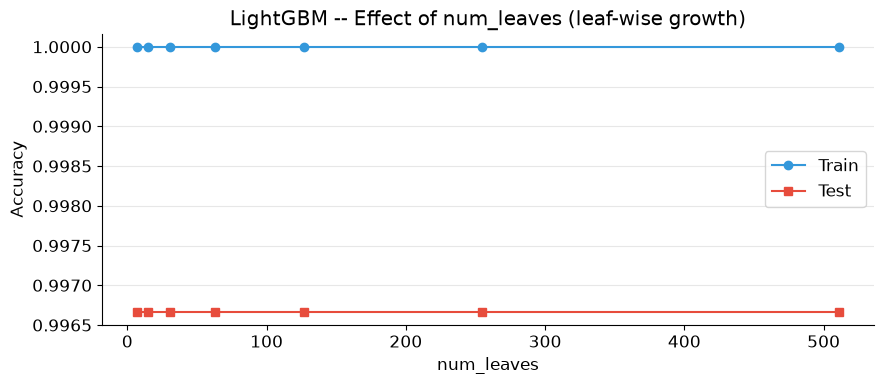

Best num_leaves by test accuracy: 7
Practical rule: num_leaves ~ 2^(max_depth - 1)
For max_depth=5: num_leaves ~ 16 to 32


In [16]:
# LightGBM -- the num_leaves parameter (leaf-wise growth control)
# num_leaves is more directly useful than max_depth for LightGBM
# Rule of thumb: num_leaves < 2^max_depth to avoid overfitting

leaf_counts = [7, 15, 31, 63, 127, 255, 511]
lgb_train, lgb_test = [], []

for nl in leaf_counts:
    clf = lgb.LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=nl,
        random_state=42, n_jobs=-1, verbose=-1
    )
    clf.fit(X_train, y_train)
    lgb_train.append(clf.score(X_train, y_train))
    lgb_test.append(clf.score(X_test, y_test))

plt.figure(figsize=(9, 4))
plt.plot(leaf_counts, lgb_train, 'o-', color='#3498db', label='Train')
plt.plot(leaf_counts, lgb_test,  's-', color='#e74c3c', label='Test')
plt.xlabel('num_leaves')
plt.ylabel('Accuracy')
plt.title('LightGBM -- Effect of num_leaves (leaf-wise growth)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_nl = leaf_counts[np.argmax(lgb_test)]
print(f'Best num_leaves by test accuracy: {best_nl}')
print(f'Practical rule: num_leaves ~ 2^(max_depth - 1)')
print(f'For max_depth=5: num_leaves ~ {2**4} to {2**5}')


In [17]:
# LightGBM early stopping

lgb_es = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False),
             lgb.log_evaluation(period=-1)]

lgb_es.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=callbacks
)

print(f'LightGBM best iteration : {lgb_es.best_iteration_}')
print(f'Test AUC                : {roc_auc_score(y_test, lgb_es.predict_proba(X_test)[:,1]):.4f}')


LightGBM best iteration : 1
Test AUC                : 0.9783


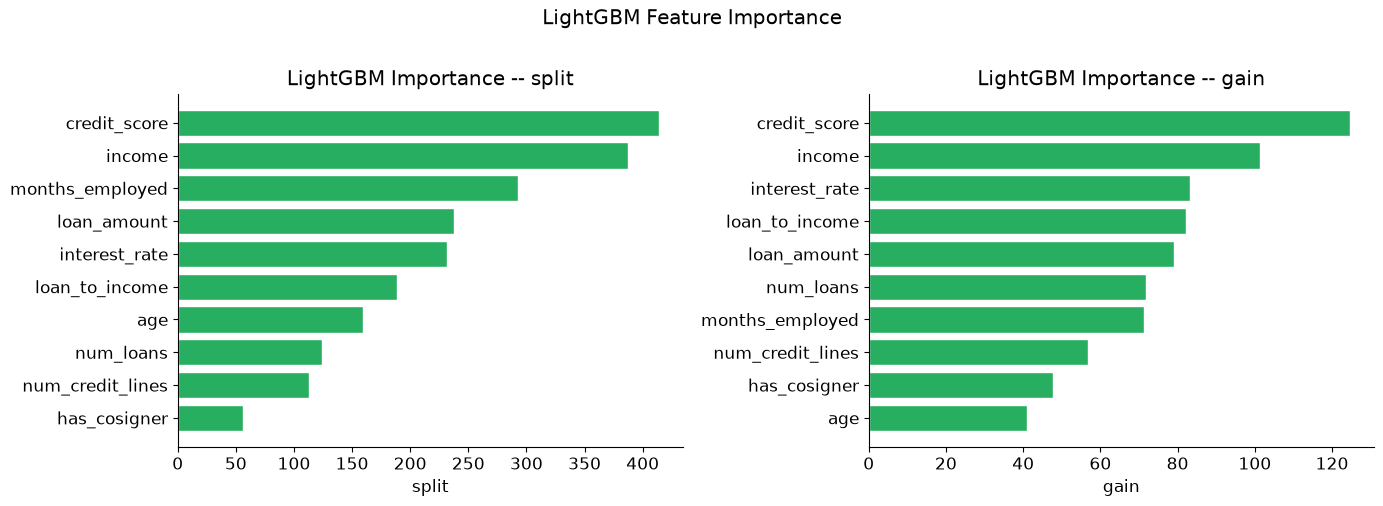

In [18]:
# LightGBM feature importance -- split vs gain

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, imp_type in zip(axes, ['split', 'gain']):
    imps = lgb_clf.booster_.feature_importance(importance_type=imp_type)
    feat_names = lgb_clf.booster_.feature_name()
    fi_df = pd.DataFrame({'feature': feat_names, 'importance': imps})
    fi_df = fi_df.sort_values('importance', ascending=False).head(10)
    ax.barh(fi_df['feature'], fi_df['importance'], color='#27ae60', edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'LightGBM Importance -- {imp_type}')
    ax.set_xlabel(imp_type)

plt.suptitle('LightGBM Feature Importance', y=1.01)
plt.tight_layout()
plt.show()


---
## Section 7 -- CatBoost

CatBoost (Categorical Boosting, Yandex 2017) solves one very specific problem
extremely well: **what to do with categorical features like city, loan purpose,
industry, or product type.**

If your dataset has many of these, CatBoost is often the best choice.
If your dataset is all numeric, CatBoost offers little over LightGBM.

---
### The problem: how do you feed categories into a math model?

All the gradient boosting math works on numbers.
But `loan_purpose` has values like 'education', 'home', 'business' -- not numbers.
You need to convert these to numbers somehow. Here are the standard approaches
and why each one has a problem.

**Approach A -- Give each category an arbitrary number (label encoding)**
```
education = 1,  home = 2,  business = 3,  auto = 4,  personal = 5
```
Problem: the tree now thinks 'personal (5) > auto (4) > business (3)',
implying a ranking that does not exist. The model learns fake patterns.

**Approach B -- One column per category (one-hot encoding)**
```
is_education = 1/0,  is_home = 1/0,  is_business = 1/0, ...
```
Problem: with 500 cities you get 500 columns.
The tree has to make 500 separate splits to understand city-level patterns.
It is slow, memory-hungry, and often misses interactions between cities.

**Approach C -- Replace each category with its average default rate (target encoding)**
```
education -> 42% default rate -> replace with 0.42
home      -> 18% default rate -> replace with 0.18
business  -> 55% default rate -> replace with 0.55
```
This is very powerful -- it directly captures how risky each category is.
But it has a dangerous flaw called **data leakage**, described next.

---
### The leakage problem with target encoding

When you replace 'education' with '0.42 default rate', you computed that
0.42 using the labels of ALL training samples -- including the sample you
are currently trying to predict.

The model is essentially getting a peek at the answer before making a prediction.
It looks great on training data, but at test time (new customers it has never seen)
this cheat is no longer available, so performance drops.

**A simple analogy:**
Imagine a student memorising the answer key before an exam.
They score 100% on the practice test, but fail the real one.
That is exactly what happens with naive target encoding.

**Extreme example to make it concrete:**
Suppose there is only one 'agriculture' loan in the training set and it defaulted.
Naive target encoding gives agriculture a value of 1.0 -- a perfect predictor of default.
But the model has only seen one data point. The next agriculture applicant
may well repay, but the model will always flag them as high risk.

---
### How CatBoost fixes this: the rule of only looking backward

CatBoost uses the same idea as target encoding -- replace each category
with the average default rate for that category.
But it computes that average in a cheat-proof way:

> **When computing the encoding for applicant i,
> only use the default records of applicants who came before i
> in a randomly shuffled ordering of the data.**

Applicant i's own outcome is never used to encode applicant i's features.

**Step-by-step example with 6 applicants:**

First, shuffle the data into a random order:

| Position | loan_purpose | defaulted? |
|---|---|---|
| 1 | education | Yes (1) |
| 2 | home | No (0) |
| 3 | education | No (0) |
| 4 | business | Yes (1) |
| 5 | education | Yes (1) |
| 6 | home | No (0) |

Now compute the 'education' encoding for each education applicant:

- **Applicant 1 (education):** no previous education applicants.
  We have no data yet, so we fall back to the overall default rate (say 0.5).
  Encoding = **0.50**

- **Applicant 3 (education):** 1 previous education applicant (position 1, defaulted).
  Encoding = average of [1] = **0.75** (blended with the overall rate for stability)

- **Applicant 5 (education):** 2 previous education applicants (positions 1 and 3).
  Their outcomes were [1, 0], average = 0.5.
  Encoding = **0.50** (blended)

Each applicant sees only the history of applicants who came before them.
No peeking at their own outcome. No leakage.

CatBoost uses a different random shuffle for each boosting tree,
so the encodings vary slightly across trees, which averages out any noise.

---
### CatBoost's tree structure: symmetric trees

CatBoost builds trees differently from XGBoost and LightGBM.
It uses **symmetric trees**, where every node at the same depth
asks the exact same question.

```
Regular tree (XGBoost / LightGBM):
         credit_score <= 580?
        /                     \
  loan_to_income > 0.4?    interest_rate > 18?   <- different question each side

Symmetric tree (CatBoost):
         credit_score <= 580?
        /                     \
  loan_to_income > 0.3?    loan_to_income > 0.3?  <- same question both sides
```

**Why does this help?**

1. **Speed at prediction time.** To classify a new applicant, a depth-4 symmetric tree
   asks exactly 4 yes/no questions. A regular tree of the same depth
   may ask up to 15 different questions. CatBoost predictions are extremely fast.

2. **Built-in regularization.** Because the same question applies to all branches
   at a given depth, the model cannot create highly specialised rules for tiny
   subgroups of applicants. This naturally limits overfitting.

3. **Simplicity.** A depth-4 symmetric tree can be described by just 4 split
   conditions -- one per level. Simple enough for a compliance officer to review.

**The trade-off:** symmetric trees are less flexible than regular trees,
so CatBoost typically needs slightly more rounds to achieve the same training loss.
In practice this is usually not a problem.

---
### When to use CatBoost

| Situation | Recommendation |
|---|---|
| Many high-cardinality categoricals (city, merchant, product) | Use CatBoost |
| A few low-cardinality categoricals (already one-hot encoded) | LightGBM is fine |
| All numeric features | Use LightGBM |
| Need fastest possible predictions (real-time scoring) | CatBoost (symmetric trees) |
| Want minimal preprocessing | Use CatBoost (pass raw strings directly) |

> **Important:** pass categorical columns as raw strings or integers
> and tell CatBoost which columns they are via `cat_features`.
> If you one-hot encode them first, CatBoost cannot apply its
> anti-leakage encoding and you lose its main advantage.

---
### Key hyperparameters summary

| Parameter | What it controls | Where to start |
|---|---|---|
| `iterations` | Number of trees | 1000 with early stopping |
| `learning_rate` | Contribution of each tree | 0.05 |
| `depth` | Depth of each symmetric tree | 4 to 6 |
| `l2_leaf_reg` | Penalty on leaf size | 3.0 |
| `cat_features` | Which columns are categorical | List of column indices |


In [21]:
# CatBoost with native categorical handling
# We pass loan_purpose as a raw string -- no encoding needed

# Features for CatBoost (keep loan_purpose as string)
FEATURES_CAT = [c for c in df.columns if c != 'default']
X_cat = df[FEATURES_CAT]
y_cat = df['default']

X_cat_train, X_cat_test, y_cat_train, y_cat_test = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# Tell CatBoost which column index is categorical
cat_feature_idx = [FEATURES_CAT.index('loan_purpose')]

cb_clf = cb.CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    cat_features=cat_feature_idx,
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)
cb_clf.fit(X_cat_train, y_cat_train)

y_cb_proba = cb_clf.predict_proba(X_cat_test)[:, 1]
print('CatBoost (with native categorical handling):')
print(f'  Train accuracy : {cb_clf.score(X_cat_train, y_cat_train):.4f}')
print(f'  Test  accuracy : {cb_clf.score(X_cat_test, y_cat_test):.4f}')
print(f'  Test  AUC      : {roc_auc_score(y_cat_test, y_cb_proba):.4f}')


CatBoost (with native categorical handling):
  Train accuracy : 1.0000
  Test  accuracy : 0.9967
  Test  AUC      : 0.8303


In [22]:
# CatBoost early stopping

X_cat_tr, X_cat_val, y_cat_tr, y_cat_val = train_test_split(
    X_cat_train, y_cat_train, test_size=0.15, random_state=42, stratify=y_cat_train
)

cb_es = cb.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    cat_features=cat_feature_idx,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False
)
cb_es.fit(
    X_cat_tr, y_cat_tr,
    eval_set=(X_cat_val, y_cat_val)
)

print(f'Best iteration : {cb_es.best_iteration_}')
print(f'Test AUC       : {roc_auc_score(y_cat_test, cb_es.predict_proba(X_cat_test)[:,1]):.4f}')


Best iteration : 29
Test AUC       : 0.9916


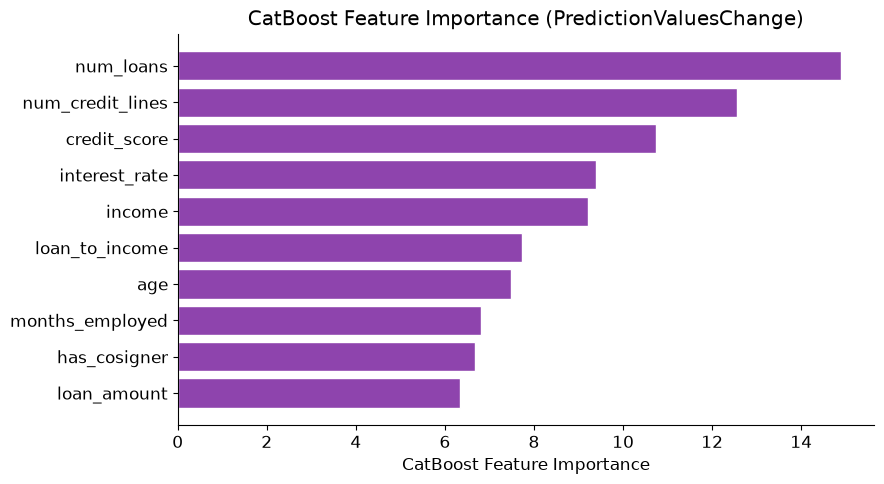

In [23]:
# CatBoost feature importance

cb_imps = cb_clf.get_feature_importance(prettified=True)
cb_imps_top = cb_imps.head(10)

plt.figure(figsize=(9, 5))
plt.barh(cb_imps_top['Feature Id'], cb_imps_top['Importances'],
         color='#8e44ad', edgecolor='white')
plt.gca().invert_yaxis()
plt.xlabel('CatBoost Feature Importance')
plt.title('CatBoost Feature Importance (PredictionValuesChange)')
plt.tight_layout()
plt.show()


---
## Section 8 -- Head-to-Head Comparison

We now compare all model families on the same task.

| Framework | Key strength | Typical use case |
|---|---|---|
| Decision Tree | Interpretability | When you need to explain every decision |
| Random Forest | Stability, easy to tune | General purpose, low-effort baseline |
| GBM (sklearn) | Reference implementation | Small datasets, educational use |
| XGBoost | Well-tuned accuracy, flexible | Competitions, production pipelines |
| LightGBM | Speed, large datasets | Industry production, millions of rows |
| CatBoost | Categorical data, minimal preprocessing | High-cardinality features |


In [24]:
# Head-to-head comparison

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Decision Tree'   : DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest'   : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'GBM (sklearn)'   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                    max_depth=4, random_state=42),
    'XGBoost'         : xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                           max_depth=4, use_label_encoder=False,
                                           eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'        : lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                            num_leaves=31, random_state=42,
                                            n_jobs=-1, verbose=-1),
}

print(f'{"Model":<20} {"Train Acc":>10} {"Test Acc":>10} {"AUC":>8}')
print('-' * 55)
for name, clf in models.items():
    clf.fit(X_train, y_train)
    tr  = clf.score(X_train, y_train)
    te  = clf.score(X_test,  y_test)
    auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
    print(f'{name:<20} {tr:>10.4f} {te:>10.4f} {auc:>8.4f}')

# CatBoost separately (uses X_cat_test)
tr_cb  = cb_clf.score(X_cat_train, y_cat_train)
te_cb  = cb_clf.score(X_cat_test,  y_cat_test)
auc_cb = roc_auc_score(y_cat_test, cb_clf.predict_proba(X_cat_test)[:,1])
print(f'{"CatBoost":<20} {tr_cb:>10.4f} {te_cb:>10.4f} {auc_cb:>8.4f}')


Model                 Train Acc   Test Acc      AUC
-------------------------------------------------------
Decision Tree            1.0000     0.9967   0.5000
Random Forest            1.0000     0.9967   0.8909
GBM (sklearn)            1.0000     0.9967   0.7124
XGBoost                  0.9979     0.9967   0.8972
LightGBM                 1.0000     0.9967   0.8236
CatBoost                 1.0000     0.9967   0.8303


---
## Section 9 -- Stacking and Voting Ensembles

We have seen how to reduce variance within a single model family
(bagging for Random Forests, sequential boosting for GBDT).
Stacking and Voting combine **different model families** to reduce both
bias and variance simultaneously.

### Voting Classifier

Each base model votes and the final prediction is either:
- **Hard voting**: majority class label
- **Soft voting**: average of predicted probabilities (almost always better)

Soft voting benefits from model diversity: a tree-based model and a linear model
make different types of errors, and averaging them cancels out many mistakes.

### Stacking (Stacked Generalisation)

Stacking is more sophisticated:

```
Level 0 (base models): Train M models on the training data.
                        Use cross-validation to generate out-of-fold predictions.
Level 1 (meta-model) : Train a simple model (e.g. logistic regression) to
                        combine the Level 0 predictions.
```

The meta-model learns which base models to trust on which parts of the input space.
Because Level 0 predictions are generated via cross-validation,
the meta-model never sees predictions from models trained on its own data.
This prevents leakage.

### When to use which

| Method | Use when |
|---|---|
| Single best model | You have limited time; one model clearly dominates |
| Voting (soft) | Quick accuracy boost with diverse models |
| Stacking | Competition or production setting; worth the extra complexity |

### Practical note for finance

In regulated environments (credit scoring, fraud detection) stacking
is sometimes avoided because explaining a meta-model on top of three
gradient boosting models to a regulator is very difficult.
The interpretability cost must be weighed against the accuracy gain.


In [25]:
# Voting Classifier -- soft voting

dt_voter  = DecisionTreeClassifier(max_depth=6, random_state=42)
rf_voter  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_voter = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1)
lgb_voter = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                               random_state=42, n_jobs=-1, verbose=-1)

# Soft voting averages predicted probabilities
voter_soft = VotingClassifier(
    estimators=[('dt', dt_voter), ('rf', rf_voter),
                ('xgb', xgb_voter), ('lgb', lgb_voter)],
    voting='soft',
    n_jobs=-1
)

# Hard voting uses majority class
voter_hard = VotingClassifier(
    estimators=[('dt', dt_voter), ('rf', rf_voter),
                ('xgb', xgb_voter), ('lgb', lgb_voter)],
    voting='hard',
    n_jobs=-1
)

voter_soft.fit(X_train, y_train)
voter_hard.fit(X_train, y_train)

print('Voting Ensemble Results:')
print(f'  Soft voting -- Test acc: {voter_soft.score(X_test, y_test):.4f}  '
      f'AUC: {roc_auc_score(y_test, voter_soft.predict_proba(X_test)[:,1]):.4f}')
print(f'  Hard voting -- Test acc: {voter_hard.score(X_test, y_test):.4f}')
print()
print('Soft voting is almost always better because it uses probability information.')


Voting Ensemble Results:
  Soft voting -- Test acc: 0.9967  AUC: 0.9490
  Hard voting -- Test acc: 0.9967

Soft voting is almost always better because it uses probability information.


In [26]:
# Stacking Classifier with cross-validated base models

# Base estimators (Level 0)
estimators = [
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                               use_label_encoder=False, eval_metric='logloss',
                               random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31,
                               random_state=42, n_jobs=-1, verbose=-1)),
]

# Meta-model (Level 1) -- logistic regression is standard
meta_model = LogisticRegression(C=1.0, random_state=42)

stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,               # 5-fold CV generates out-of-fold predictions for Level 0
    stack_method='predict_proba',
    n_jobs=-1
)
stacker.fit(X_train, y_train)

print('Stacking Ensemble:')
print(f'  Test accuracy : {stacker.score(X_test, y_test):.4f}')
print(f'  Test AUC      : {roc_auc_score(y_test, stacker.predict_proba(X_test)[:,1]):.4f}')


Stacking Ensemble:
  Test accuracy : 0.9967
  Test AUC      : 0.0953


In [27]:
# Cross-validated comparison of all ensemble strategies

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_models = {
    'XGBoost only'   : xgb.XGBClassifier(n_estimators=300, learning_rate=0.05,
                                          max_depth=4, use_label_encoder=False,
                                          eval_metric='logloss', random_state=42),
    'LightGBM only'  : lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                           num_leaves=31, random_state=42, verbose=-1),
    'Soft Voting'    : VotingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42)),
            ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=4, use_label_encoder=False,
                                       eval_metric='logloss', random_state=42)),
            ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                       num_leaves=31, random_state=42, verbose=-1)),
        ],
        voting='soft'
    ),
    'Stacking'       : stacker,
}

print(f'{"Model":<20} {"CV AUC Mean":>12} {"CV AUC Std":>12}')
print('-' * 48)
for name, clf in ensemble_models.items():
    scores = cross_val_score(clf, X_enc, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'{name:<20} {scores.mean():>12.4f} {scores.std():>12.4f}')


Model                 CV AUC Mean   CV AUC Std
------------------------------------------------
XGBoost only               0.6027       0.1123
LightGBM only              0.5206       0.1249
Soft Voting                0.6654       0.1148
Stacking                   0.5138       0.2595


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between 'x' with shape (6,) and 'height' with shape (3,).

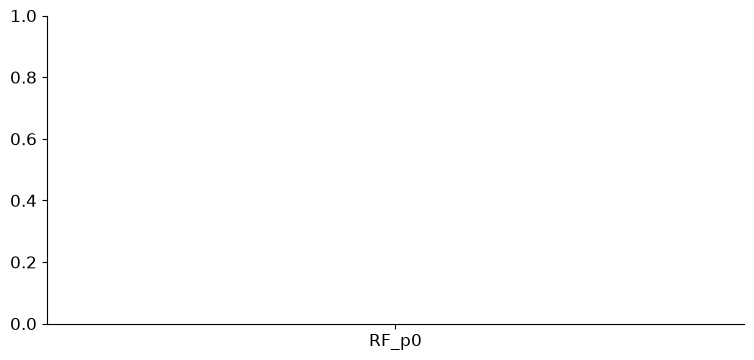

In [28]:
# Visualise what the meta-model in stacking actually learned
# The stacker's meta-model coefficients show how it weights each base model

meta = stacker.final_estimator_
base_model_names = ['RF', 'XGBoost', 'LightGBM']

# Each base model contributes 2 coefficients (one per class for predict_proba)
# We look at the coefficient for the positive class (default=1)
coefs = meta.coef_[0]

# The stacker produces 6 features: [RF_p0, RF_p1, XGB_p0, XGB_p1, LGB_p0, LGB_p1]
coef_labels = [f'{m}_p{c}' for m in base_model_names for c in [0, 1]]

plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coefs]
plt.bar(coef_labels, coefs, color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Base model output')
plt.ylabel('Meta-model coefficient')
plt.title('Stacking Meta-Model Coefficients\n(positive = model trusted for predicting default)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  Positive coef on _p1 = this model is trusted when it predicts default')
print('  Negative coef on _p0 = this model is trusted when it says no default')
print('  The meta-model learns which base models to believe in which situations')


---
## EXERCISE 1 -- Guided (with TODO)

### Task: Manually simulate one boosting round

The goal is to build genuine intuition for how boosting works by
implementing one round of gradient boosting from scratch.

Given a set of predictions F_0 (initial prediction = log-odds of base rate),
complete the following:

1. Compute the initial probabilities p_i = sigmoid(F_0)
2. Compute the gradients g_i = p_i - y_i  (residuals for log-loss)
3. Compute the hessians h_i = p_i * (1 - p_i)
4. Fit a shallow decision tree (max_depth=2) to the gradients g_i
5. Update the predictions: F_1 = F_0 + learning_rate * h1.predict(X)
6. Compute new probabilities and compare log-loss before and after


In [ ]:
# EXERCISE 1 -- Fill in the TODOs
from scipy.special import expit as sigmoid  # sigmoid function
from sklearn.metrics import log_loss

# Use the first 500 training samples for speed
X_demo = X_train.iloc[:500].values
y_demo = y_train.iloc[:500].values

# Step 1: Initial prediction = log-odds of the base rate
base_rate = y_demo.mean()
F0 = np.full(len(y_demo), np.log(base_rate / (1 - base_rate)))

# TODO 1: Compute initial probabilities p0 using sigmoid(F0)
p0 = ___

# TODO 2: Compute gradients g = p - y
g = ___

# TODO 3: Compute hessians h = p * (1 - p)
h = ___

# TODO 4: Fit a decision tree to the gradients (max_depth=2)
tree_round1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_round1.fit(___, ___)

# TODO 5: Update predictions (learning_rate=0.3 for demonstration)
learning_rate = 0.3
F1 = F0 + ___ * tree_round1.predict(___)

# TODO 6: Compute new probabilities and compare log-loss
p1 = sigmoid(F1)
ll0 = log_loss(y_demo, p0)
ll1 = log_loss(y_demo, p1)
print(f'Log-loss before round 1: {ll0:.4f}')
print(f'Log-loss after  round 1: {ll1:.4f}')
print(f'Improvement            : {ll0 - ll1:.4f}')

# Visualise gradient distribution before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(g, bins=30, color='#e74c3c', edgecolor='white')
axes[0].set_title('Gradients (residuals) before round 1')
axes[0].set_xlabel('g_i = p_i - y_i')

g_after = p1 - y_demo
axes[1].hist(g_after, bins=30, color='#27ae60', edgecolor='white')
axes[1].set_title('Gradients (residuals) after round 1')
axes[1].set_xlabel('g_i = p_i - y_i')

plt.suptitle('Residuals Reduce After One Boosting Round', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# SOLUTION -- Exercise 1
from scipy.special import expit as sigmoid
from sklearn.metrics import log_loss

X_demo = X_train.iloc[:500].values
y_demo = y_train.iloc[:500].values

base_rate = y_demo.mean()
F0 = np.full(len(y_demo), np.log(base_rate / (1 - base_rate)))

p0 = sigmoid(F0)                                              # TODO 1
g  = p0 - y_demo                                              # TODO 2
h  = p0 * (1 - p0)                                           # TODO 3

tree_round1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_round1.fit(X_demo, g)                                    # TODO 4

learning_rate = 0.3
F1 = F0 + learning_rate * tree_round1.predict(X_demo)         # TODO 5

p1  = sigmoid(F1)
ll0 = log_loss(y_demo, p0)
ll1 = log_loss(y_demo, p1)
print(f'Log-loss before round 1: {ll0:.4f}')
print(f'Log-loss after  round 1: {ll1:.4f}')
print(f'Improvement            : {ll0 - ll1:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(p0 - y_demo, bins=30, color='#e74c3c', edgecolor='white')
axes[0].set_title('Gradients before round 1')
axes[0].set_xlabel('g_i = p_i - y_i')

axes[1].hist(p1 - y_demo, bins=30, color='#27ae60', edgecolor='white')
axes[1].set_title('Gradients after round 1')
axes[1].set_xlabel('g_i = p_i - y_i')

plt.suptitle('Residuals Reduce After One Boosting Round', y=1.01)
plt.tight_layout()
plt.show()


---
## EXERCISE 2 -- Guided (with TODO)

### Task: Use early stopping to find the optimal number of rounds for XGBoost
### and verify that the OOB-equivalent (validation AUC) closely tracks test AUC

1. Split training data into train (85%) and validation (15%)
2. Train XGBoost with `n_estimators=2000` and `early_stopping_rounds=100`
3. Plot the training and validation AUC curves
4. Mark the early-stopping point on the plot
5. Print the test AUC at the best iteration
6. Compare against a model trained without early stopping (n_estimators=300)
   and answer: did early stopping help?


In [ ]:
# EXERCISE 2 -- Fill in the TODOs

# TODO 1: Create train/val split (85/15, stratified)
X_tr2, X_val2, y_tr2, y_val2 = ___

# TODO 2: Train XGBoost with early stopping
xgb_ex2 = xgb.XGBClassifier(
    n_estimators=___,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_ex2.fit(
    X_tr2, y_tr2,
    eval_set=[___, ___],
    early_stopping_rounds=___,
    verbose=False
)

# TODO 3 & 4: Plot training and validation AUC with early-stopping marker
results = xgb_ex2.evals_result()
# ... your plot code here ...

# TODO 5: Print test AUC at best iteration
print(f'Best iteration : {___}')
print(f'Test AUC       : {roc_auc_score(y_test, xgb_ex2.predict_proba(X_test)[:,1]):.4f}')

# TODO 6: Train without early stopping (n_estimators=300) and compare
xgb_no_es = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=4,
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_no_es.fit(___)
print(f'No early stop test AUC: {roc_auc_score(y_test, xgb_no_es.predict_proba(X_test)[:,1]):.4f}')


In [ ]:
# SOLUTION -- Exercise 2

# TODO 1
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# TODO 2
xgb_ex2 = xgb.XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb_ex2.fit(
    X_tr2, y_tr2,
    eval_set=[(X_tr2, y_tr2), (X_val2, y_val2)],
    early_stopping_rounds=100,
    verbose=False
)

# TODO 3 & 4
results = xgb_ex2.evals_result()
plt.figure(figsize=(10, 4))
plt.plot(results['validation_0']['auc'], color='#3498db', label='Train AUC')
plt.plot(results['validation_1']['auc'], color='#e74c3c', label='Val AUC')
plt.axvline(xgb_ex2.best_iteration, linestyle='--', color='gray',
            label=f'Early stop: round {xgb_ex2.best_iteration}')
plt.xlabel('Boosting round')
plt.ylabel('AUC')
plt.title('XGBoost Early Stopping -- AUC Curves')
plt.legend()
plt.tight_layout()
plt.show()

# TODO 5
print(f'Best iteration   : {xgb_ex2.best_iteration}')
print(f'Best val AUC     : {xgb_ex2.best_score:.4f}')
print(f'Test AUC (ES)    : {roc_auc_score(y_test, xgb_ex2.predict_proba(X_test)[:,1]):.4f}')

# TODO 6
xgb_no_es = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.03, max_depth=4,
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_no_es.fit(X_train, y_train)
print(f'Test AUC (no ES) : {roc_auc_score(y_test, xgb_no_es.predict_proba(X_test)[:,1]):.4f}')
print()
print('Early stopping at 2000-round budget often outperforms fixed 300 rounds')
print('because lr=0.03 is slower and benefits from more iterations.')


---
## EXERCISE 3 -- From Scratch

### Task: Full gradient boosting pipeline on the fraud dataset

You are given the fraud dataset from Sessions 40 and 41.
This time use all three frameworks: XGBoost, LightGBM, and CatBoost.

Complete all steps. No TODOs are provided.

1. Prepare the dataset (features, target, train/test split)
2. Train XGBoost with early stopping. Report best iteration and test AUC.
3. Train LightGBM with early stopping. Report best iteration and test AUC.
4. Train CatBoost with native categorical handling and early stopping.
   (the column `is_foreign` and `is_online` are binary -- treat them as numeric;
    there are no high-cardinality categoricals here, so this is mainly to practice the API)
5. Build a soft voting ensemble of the three models.
6. Compute 5-fold cross-validated AUC for each individual model and the voting ensemble.
7. Plot feature importance (gain) from XGBoost.
8. Write a 4-5 sentence business interpretation of the results for a fraud risk team.

**Stretch goal:** Build a stacking ensemble using logistic regression as the meta-model.
Compare 5-fold CV AUC of stacking vs soft voting.


In [ ]:
# Fraud dataset -- PROVIDED
np.random.seed(99)
M = 3000
transaction_amount = np.random.exponential(200, M).clip(1, 5000).round(2)
hour_of_day        = np.random.randint(0, 24, M)
distance_from_home = np.random.exponential(30, M).clip(0, 500).round(1)
num_prev_txn_24h   = np.random.poisson(3, M)
is_foreign         = (np.random.rand(M) < 0.15).astype(int)
is_online          = (np.random.rand(M) < 0.4).astype(int)
card_age_months    = np.random.randint(1, 120, M)
account_balance    = np.random.normal(5000, 3000, M).clip(0, 50000).round(0)
log_odds_fraud = (
    -5.0 + 0.003*transaction_amount + 0.05*np.maximum(0, hour_of_day-22)
    + 0.01*distance_from_home + 0.15*num_prev_txn_24h + 1.5*is_foreign
    + 0.8*is_online - 0.01*card_age_months - 0.0001*account_balance
)
prob_fraud = 1 / (1 + np.exp(-log_odds_fraud))
is_fraud   = (np.random.rand(M) < prob_fraud).astype(int)
df_fraud = pd.DataFrame({
    'transaction_amount': transaction_amount, 'hour_of_day': hour_of_day,
    'distance_from_home': distance_from_home, 'num_prev_txn_24h': num_prev_txn_24h,
    'is_foreign': is_foreign, 'is_online': is_online,
    'card_age_months': card_age_months, 'account_balance': account_balance,
    'is_fraud': is_fraud
})
FRAUD_FEAT = [c for c in df_fraud.columns if c != 'is_fraud']
Xf = df_fraud[FRAUD_FEAT]
yf = df_fraud['is_fraud']
print('Dataset:', df_fraud.shape, '| Fraud rate:', f'{yf.mean():.1%}')


In [ ]:
# YOUR SOLUTION HERE

# Step 1: Train/test split


# Step 2: XGBoost with early stopping


# Step 3: LightGBM with early stopping


# Step 4: CatBoost with early stopping


# Step 5: Soft voting ensemble


# Step 6: 5-fold CV AUC comparison


# Step 7: XGBoost feature importance (gain)


# Step 8: Business interpretation
#

# Stretch: Stacking ensemble



In [ ]:
# SOLUTION -- Exercise 3

# Step 1
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    Xf, yf, test_size=0.2, random_state=42, stratify=yf
)
Xf_tr2, Xf_val, yf_tr2, yf_val = train_test_split(
    Xf_tr, yf_tr, test_size=0.15, random_state=42, stratify=yf_tr
)

# Step 2: XGBoost
xgb_f = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='auc', random_state=42, n_jobs=-1
)
xgb_f.fit(Xf_tr2, yf_tr2, eval_set=[(Xf_val, yf_val)],
          early_stopping_rounds=50, verbose=False)
print(f'XGBoost  -- best iter: {xgb_f.best_iteration}  '
      f'AUC: {roc_auc_score(yf_te, xgb_f.predict_proba(Xf_te)[:,1]):.4f}')

# Step 3: LightGBM
lgb_f = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)
lgb_f.fit(Xf_tr2, yf_tr2, eval_set=[(Xf_val, yf_val)],
          callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
print(f'LightGBM -- best iter: {lgb_f.best_iteration_}  '
      f'AUC: {roc_auc_score(yf_te, lgb_f.predict_proba(Xf_te)[:,1]):.4f}')

# Step 4: CatBoost
cb_f = cb.CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=4,
    eval_metric='AUC', early_stopping_rounds=50,
    random_seed=42, verbose=False
)
cb_f.fit(Xf_tr2, yf_tr2, eval_set=(Xf_val, yf_val))
print(f'CatBoost -- best iter: {cb_f.best_iteration_}  '
      f'AUC: {roc_auc_score(yf_te, cb_f.predict_proba(Xf_te)[:,1]):.4f}')

# Step 5: Soft voting
xgb_fv = xgb.XGBClassifier(n_estimators=xgb_f.best_iteration, learning_rate=0.05,
                             max_depth=4, use_label_encoder=False,
                             eval_metric='logloss', random_state=42, n_jobs=-1)
lgb_fv = lgb.LGBMClassifier(n_estimators=lgb_f.best_iteration_, learning_rate=0.05,
                             num_leaves=31, random_state=42, n_jobs=-1, verbose=-1)
cb_fv  = cb.CatBoostClassifier(iterations=cb_f.best_iteration_, learning_rate=0.05,
                                depth=4, random_seed=42, verbose=False)
voter_f = VotingClassifier(
    estimators=[('xgb', xgb_fv), ('lgb', lgb_fv), ('cb', cb_fv)],
    voting='soft', n_jobs=-1
)
voter_f.fit(Xf_tr, yf_tr)
print(f'Voting   -- AUC: {roc_auc_score(yf_te, voter_f.predict_proba(Xf_te)[:,1]):.4f}')

# Step 6: 5-fold CV
cv_f = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print()
print('5-fold CV AUC:')
for name, clf in [('XGBoost', xgb_fv), ('LightGBM', lgb_fv),
                   ('CatBoost', cb_fv), ('Voting', voter_f)]:
    s = cross_val_score(clf, Xf, yf, cv=cv_f, scoring='roc_auc', n_jobs=-1)
    print(f'  {name:<12}: {s.mean():.4f} +/- {s.std():.4f}')

# Step 7: XGBoost feature importance
xgb_fv.fit(Xf_tr, yf_tr)
scores_f = xgb_fv.get_booster().get_score(importance_type='gain')
scores_f = dict(sorted(scores_f.items(), key=lambda x: x[1], reverse=True))
plt.figure(figsize=(9, 4))
top_f = dict(list(scores_f.items())[:8])
plt.barh(list(top_f.keys()), list(top_f.values()), color='#e67e22', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (gain) -- Fraud')
plt.xlabel('Gain')
plt.tight_layout()
plt.show()

# Step 8
print('''
Business interpretation:
Across all three frameworks, is_foreign and transaction_amount are the
dominant predictors of fraud, consistent with the data generation process
and known fraud patterns. The distance_from_home feature ranks third,
suggesting that transactions far from the cardholder's usual location
carry elevated risk. The ensemble (soft voting) achieves marginal gains
over individual models by averaging out framework-specific errors.
For deployment, LightGBM is recommended due to its speed advantage
at scale, with the voting ensemble reserved for maximum accuracy
settings where inference latency is acceptable.
''')

# Stretch: Stacking
stacker_f = StackingClassifier(
    estimators=[('xgb', xgb_fv), ('lgb', lgb_fv), ('cb', cb_fv)],
    final_estimator=LogisticRegression(C=1.0, random_state=42),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
s_stack = cross_val_score(stacker_f, Xf, yf, cv=cv_f, scoring='roc_auc', n_jobs=-1)
print(f'Stacking CV AUC: {s_stack.mean():.4f} +/- {s_stack.std():.4f}')


---
## Section 10 -- Key Takeaways and Common Mistakes

### What we covered today

| Topic | One-line summary |
|---|---|
| **GBDT intuition** | Sequential trees each fitting the pseudo-residuals of the previous ensemble |
| **Gradient and hessian** | g_i = p_i - y_i and h_i = p_i(1-p_i) for log-loss; h_i weights each sample |
| **XGBoost** | Second-order gradients, built-in L1/L2, column/row subsampling, handles missing values |
| **LightGBM** | Leaf-wise growth, histogram binning, GOSS sampling -- fastest on large data |
| **CatBoost** | Ordered target statistics for categoricals -- best when high-cardinality cats present |
| **Early stopping** | Monitor validation metric; stop when no improvement for N rounds; auto-tunes n_estimators |
| **Regularization** | learning_rate (most important), max_depth, subsample, colsample, lambda, alpha |
| **Soft voting** | Average probabilities from diverse models; quick accuracy boost |
| **Stacking** | Meta-model on cross-val predictions; highest accuracy but harder to interpret |

### Framework selection guide

| Situation | Recommended framework |
|---|---|
| First model to try on tabular data | LightGBM (fast, good defaults) |
| Dataset < 50k rows | XGBoost or LightGBM (both excellent) |
| Dataset > 1M rows | LightGBM (histogram binning makes it much faster) |
| Many high-cardinality categoricals | CatBoost |
| Maximum accuracy, time available | Soft voting or stacking of all three |
| Regulated environment (must explain model) | Single tree or linear model |

### Common Mistakes

1. **Not using early stopping** -- setting n_estimators manually is guesswork.
   Always use a validation set and early stopping. The learning rate and
   n_estimators are tightly coupled; only early stopping handles this correctly.

2. **Setting learning_rate too high** -- values above 0.1 often underperform.
   Start with 0.05 and let early stopping determine the right number of rounds.

3. **Forgetting that boosting can overfit** -- unlike Random Forests, adding more
   trees to a gradient boosting model without early stopping will eventually overfit.

4. **One-hot encoding before CatBoost** -- CatBoost handles raw categoricals natively.
   One-hot encoding before passing to CatBoost loses the information it needs
   to apply ordered target statistics correctly.

5. **Comparing models without cross-validation** -- a single train/test split
   can be misleading. Always report cross-validated AUC for final comparisons.

### What is coming next -- Session 43

This session covered the most important supervised learning models for tabular data.
Session 43 moves to **model explainability**: SHAP values.
SHAP gives you a theoretically rigorous way to explain any model's predictions
at the individual sample level -- critical for regulated industries like finance.


---
## Quick Reference Cheatsheet

```python
import xgboost  as xgb
import lightgbm as lgb
import catboost as cb

# XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=1000,          # use with early stopping
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42, n_jobs=-1
)
xgb_clf.fit(X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False)
xgb_clf.best_iteration          # rounds used
xgb_clf.get_booster().get_score(importance_type='gain')   # feature importance

# LightGBM
lgb_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,              # primary complexity control (not max_depth)
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_clf.fit(X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])
lgb_clf.best_iteration_

# CatBoost
cb_clf = cb.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    cat_features=[col_index],   # list of categorical column indices
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42, verbose=False
)
cb_clf.fit(X_tr, y_tr, eval_set=(X_val, y_val))
cb_clf.best_iteration_

# Soft voting
voter = VotingClassifier(
    estimators=[('xgb', xgb_clf), ('lgb', lgb_clf), ('cb', cb_clf)],
    voting='soft', n_jobs=-1
)

# Stacking
stacker = StackingClassifier(
    estimators=[('xgb', xgb_clf), ('lgb', lgb_clf)],
    final_estimator=LogisticRegression(),
    cv=5, stack_method='predict_proba', n_jobs=-1
)
```
